# Temas Tratados en el Trabajo Práctico 8

* Aprendizaje estadístico.

* Evolución de la verosimilitud de una hipótesis en función de observaciones.

* Aprendizaje no supervisado. Algoritmo K-means.

* Aprendizaje supervisado. Algoritmo Knn.

* Aprendizaje por refuerzo. Algoritmo Q-Learning.

## Ejercicios Teóricos

1. Un fabricante de tornillos vende cajas que contienen 1000 tornillos de cabeza redonda con tres tipos de recubrimiento electrolítico (cincado, cobre y níquel). Cada caja se rellena
con diferentes proporciones que pueden variar de la siguiente manera:

&emsp;&emsp;a: Todos los tornillos están recubiertos de níquel. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;b: El 70% de los tornillos están recubiertos de níquel, el 20% de cobre, el resto está cincado. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;c: El 50% de los tornillos están recubiertos de níquel, el 25% de cobre y el resto está cincado. 50 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;d: El 20 % de los tornillos están recubiertos de níquel, el 50% de cobre y el resto está cincado. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;e: Todos los tornillos están recubiertos de cobre. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;1.1 ¿Cuál es la distribución a priori sobre las hipótesis?

&emsp;Considerando que los 10 primeros tornillos que se extraen de una caja de muestra son de cobre:

&emsp;&emsp;1.2 Calcule la probabilidad de cada hipótesis dado que los 10 primeros tornillos fueron de cobre.


&emsp;&emsp;1.3 Grafique la evolución de la verosimilitud de cada hipótesis en función del número de tornillos extraídos de la caja.

&emsp;&emsp;1.4 Para cada hipótesis, ¿cuál es la probabilidad de que el cuarto tornillo extraído sea de cobre?

2. ¿Qué diferencia principal existe entre un algoritmo supervisado y un algoritmo no supervisado?

## Ejercicios de implementación

3. Genere un conjunto de 23 puntos que contengan coordenadas *xy* aleatorias con valores contenidos en el intervalo [0, 5] y grafique los puntos obtenidos en un gráfico.

&emsp;&emsp;3.1 Implemente un algoritmo K-means que clasifique 20 de los puntos en 2 grupos y grafique el resultado asignando un color a cada uno.

&emsp;&emsp;3.2 Tome los tres puntos restantes y clasifíquelos en los grupos obtenidos anteriormente usando el algoritmo Knn. Utilice distintos valores de K y anote lo que observa con esta elección.

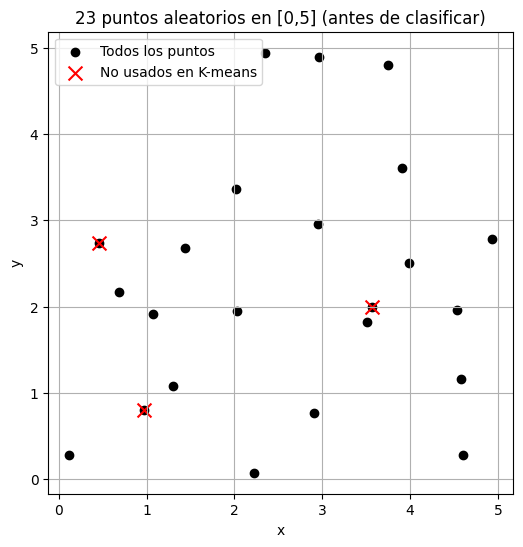

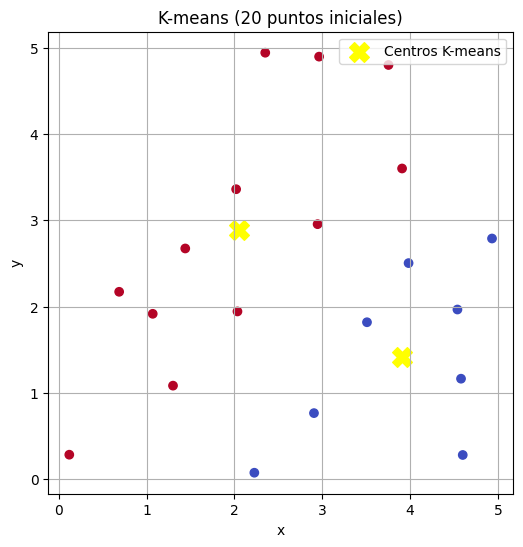

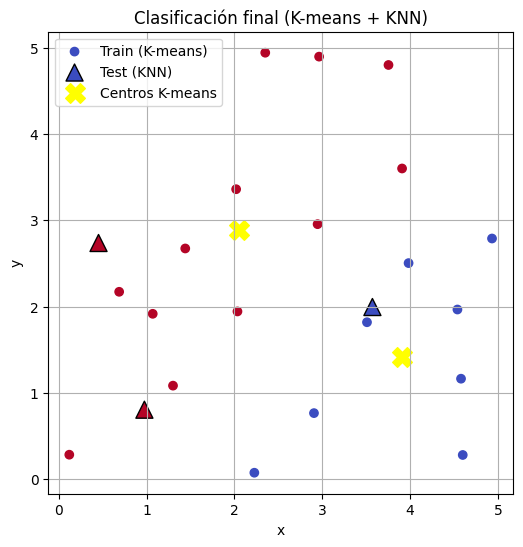

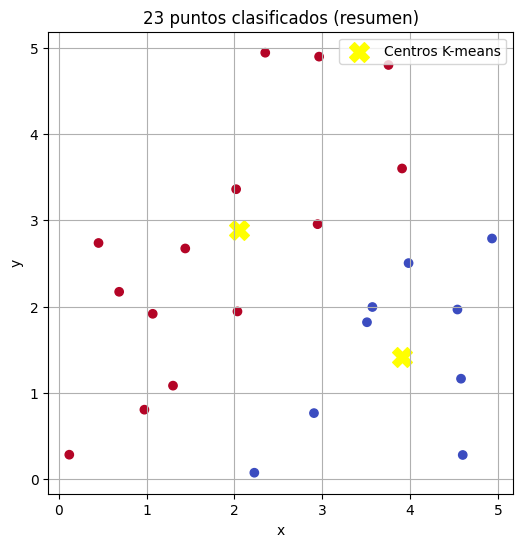

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

semilla = 24421573

# 1. Generar 23 puntos aleatorios (x, y) en [0, 5]
np.random.seed(semilla)  # Semilla fija para reproducibilidad
puntos = np.random.uniform(0, 5, (23, 2))

# Dividir en entrenamiento (20 puntos) y prueba (3 puntos)
puntos_train = puntos[:20]
puntos_test = puntos[20:]

# 2. Graficar los 23 puntos originales y marcar con X los no usados
plt.figure(figsize=(6,6))
plt.scatter(puntos[:,0], puntos[:,1], c='black', marker='o', label="Todos los puntos")
plt.scatter(puntos_test[:,0], puntos_test[:,1], c='red', marker='x', s=100, label="No usados en K-means")
plt.title("23 puntos aleatorios en [0,5] (antes de clasificar)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 3. K-means con 2 clusters en los primeros 20 puntos
kmeans = KMeans(n_clusters=2, random_state=semilla)
kmeans.fit(puntos_train)

labels_train = kmeans.labels_
centros = kmeans.cluster_centers_

# Graficar K-means con 20 puntos
plt.figure(figsize=(6,6))
plt.scatter(puntos_train[:,0], puntos_train[:,1], c=labels_train, cmap='coolwarm', marker='o')
plt.scatter(centros[:,0], centros[:,1], c='yellow', marker='X', s=200, label="Centros K-means")
plt.title("K-means (20 puntos iniciales)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 4. Entrenar un clasificador KNN usando los labels de K-means
knn = KNeighborsClassifier(n_neighbors=3)  # <--- Valor de k ! 
knn.fit(puntos_train, labels_train)

# Predecir los 3 puntos restantes
labels_test = knn.predict(puntos_test)

# Graficar clasificación final (23 puntos: train + test)
plt.figure(figsize=(6,6))
plt.scatter(puntos_train[:,0], puntos_train[:,1], c=labels_train, cmap='coolwarm', marker='o', label="Train (K-means)")
plt.scatter(puntos_test[:,0], puntos_test[:,1], c=labels_test, cmap='coolwarm', marker='^', s=150, edgecolors='black', label="Test (KNN)")
plt.scatter(centros[:,0], centros[:,1], c='yellow', marker='X', s=200, label="Centros K-means")
plt.title("Clasificación final (K-means + KNN)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 5. Resumen: mostrar los 23 puntos clasificados
# Unir labels_train y labels_test para graficar todo junto
labels_final = np.concatenate([labels_train, labels_test])

plt.figure(figsize=(6,6))
plt.scatter(puntos[:,0], puntos[:,1], c=labels_final, cmap='coolwarm', marker='o')
plt.scatter(centros[:,0], centros[:,1], c='yellow', marker='X', s=200, label="Centros K-means")
plt.title("23 puntos clasificados (resumen)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


4. La imagen mostrada abajo muestra una red de salas y cómo se comunican entre ellas. Implemente un algoritmo Q-Learning con un factor despreciativo $γ = 0.9$. La matriz de recompensas debe asignar un valor de 0 a cada camino accesible y un valor de 100 a caminos que lleven a la sala del tesoro.

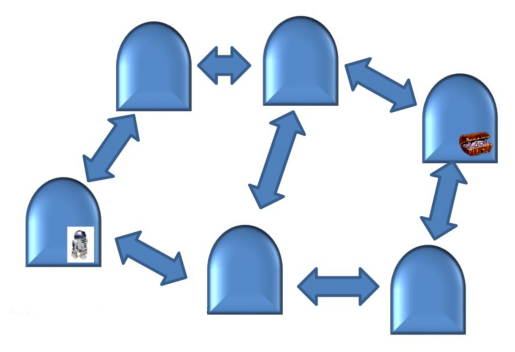

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1dkDruEIPa7f-BAmjI47TZl3bxaqYf6a9"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

&emsp;&emsp;4.1 Dibuje un diagrama con la asignación de recompensas correspondiente a cada estado.

&emsp;&emsp;4.2 Diseñe y muestre la matriz de recompensas.

&emsp;&emsp;4.3 Obtenga la matriz Q óptima, normalícela respecto al valor máximo encontrado y grafique la política obtenida en el diagrama mostrado inicialmente.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2017) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)